In [1]:
import torch
import torch.nn as nn
import os
import sys

sys.path.append('../')

import numpy as np
import math
import scipy.special as bessel
from scipy.io import loadmat
import pickle
import importlib
import DRLPDE.neuralnets as neuralnets
import DRLPDE.create as create

#import DRLPDE.plotting as tools

import matplotlib.pyplot as plt
import cv2

import matplotlib as mpl

mpl.rcParams['figure.dpi']= 300
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['font.size'] = 12

In [2]:
loadmodel = 'Heatexample'


In [3]:
with open('../experiments/' + 'dummy' + '_parameters.pickle', 'rb') as f:
    parameters = pickle.load(f)

param = importlib.import_module(".Heatexample", package='examples')

input_dim = [param.x_dim, param.t_dim, param.hyper_dim]
input_range = param.boundingbox + param.t_range + param.hyper_range
output_dim = param.output_dim

problem_parameters = {'input_dim': [param.x_dim, param.t_dim, param.hyper_dim],
                    'output_dim': param.output_dim,
                    'input_range': param.boundingbox + param.t_range + param.hyper_range,
                    'Boundaries': [param.boundingbox,
                                    param.list_of_walls, 
                                    param.solid_walls, 
                                    param.inlet_outlet, 
                                    param.list_of_periodic_ends, 
                                    param.mesh]}

if parameters['neuralnetwork'] == 'FeedForward':
    MyNeuralNetwork = neuralnets.FeedForwardNN
elif parameters['neuralnetwork'] == 'Incompressible':
    MyNeuralNetwork = neuralnets.IncompressibleNN
elif parameters['neuralnetwork'] == 'ResNet':
    MyNeuralNetwork = neuralnets.ResNetNN
elif parameters['neuralnetwork'] == 'ResNetIncompressible':
    MyNeuralNetwork = neuralnets.ResNetIncompressible

nn_size = parameters['nn_size']

model = MyNeuralNetwork(input_dim, output_dim, **nn_size)
model.load_state_dict(torch.load("../savedmodels/" + loadmodel + ".pt", map_location=torch.device('cpu')))

<All keys matched successfully>

In [4]:
[ [xmin, xmax], [ymin, ymax]] =  param.boundingbox

#num_x = 256
#num_y = 128

true_fun = param.true_fun
polar_eq = param.polar_eq

num_th = 120
num_r = 20

th = torch.linspace(0,2*math.pi, num_th)
r = torch.zeros(num_r, num_th)
for ii in range(num_th):
    r[:,ii] = torch.sqrt( torch.linspace( 0, 1, num_r) )*polar_eq(th[ii])
r = r.reshape(-1)

rth = torch.stack((r, th.repeat(num_r)), dim=1)
X = torch.stack( (rth[:,0]*torch.cos( rth[:,1] ), rth[:,0]*torch.sin( rth[:,1]), torch.zeros(num_th*num_r)), dim=1)

#X = X[num_th-1:,:]
#size = num_th*(num_r-1) + 1 

u0 = model(X).detach().reshape(num_r, num_th).numpy()

X[:,2] = 1.0

u1 = model(X).detach().reshape(num_r, num_th).numpy()

X[:,2] = 2.0

u2 = model(X).detach().reshape(num_r, num_th).numpy()

Xplot = X[:,0].detach().reshape(num_r, num_th).numpy()
Yplot = X[:,1].detach().reshape(num_r, num_th).numpy()

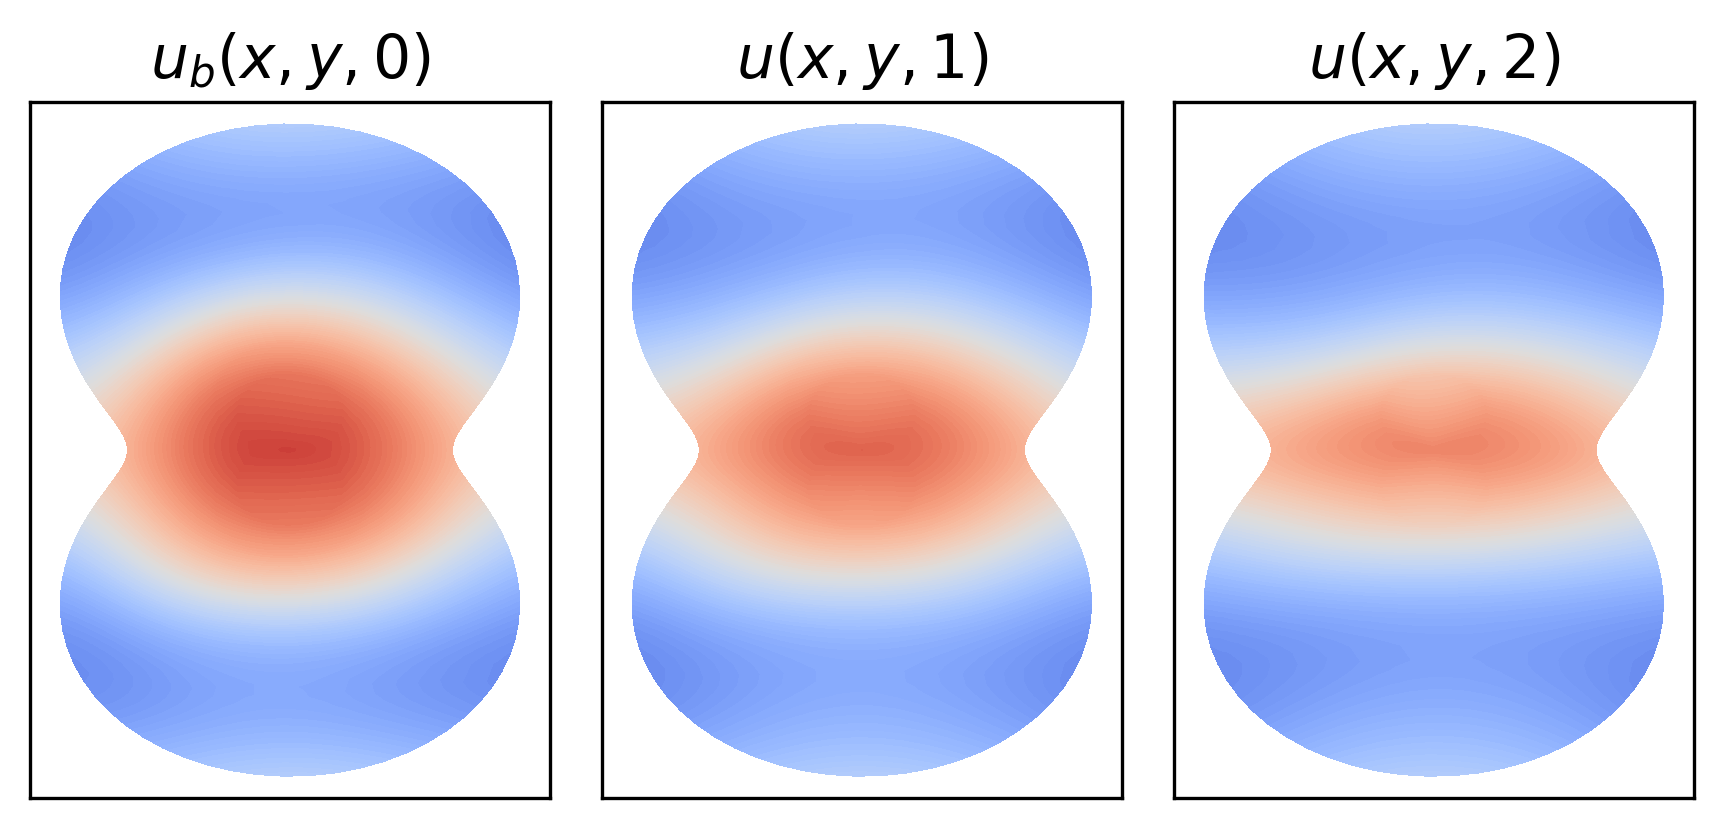

In [21]:
fig = plt.figure(figsize=[6.4 ,3.0])

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

levels = np.linspace(-1.0, 1.1, 101)

plt.tight_layout()

ax0.set_title(r'$u_b(x,y,0)$')

ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymin, ymax)
contour0 = ax0.contourf( Xplot, Yplot, u0, levels=levels, cmap=plt.cm.coolwarm)
ax0.tick_params(
    axis='both',
    which='both',
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False
)

ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)
ax1.set_title(r'$u(x,y,1)$')
contour1 = ax1.contourf( Xplot, Yplot, u1, levels=levels, cmap=plt.cm.coolwarm)
ax1.tick_params(
    axis='both',
    which='both',
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False
)

ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)
ax2.set_title(r'$u(x,y,2)$')
contour2 = ax2.contourf( Xplot, Yplot, u2, levels = levels, cmap=plt.cm.coolwarm)
ax2.tick_params(
    axis='both',
    which='both',
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False
)
plt.subplots_adjust(wspace=0.1, hspace=0)

import os

plt.savefig('Heat.png')


In [12]:
os.path.exists('~/Research/DRLPDE/images/')

False